Link Prediction using GNN



This notebook walks through the process of predicting future collaborations between authors using a Graph Neural Network (GNN). We use the `ogbl-collab` dataset.

## Link Prediction

The `ogbl-collab` dataset represents a collaboration network where:
- **Nodes**: Authors, each with a 128-dimensional feature vector.
- **Edges**: Collaborations between authors, marked by year.

**Goal**: Given past collaborations, predict future ones. We evaluate this by ranking true future collaborations against a large set of non-existent (negative) ones. The primary metric is **Hits@50**, which measures how often the true collaboration is ranked within the top 50 candidates.

### 1. Setup and Dependencies

First, we install and import the required libraries.

In [ ]:
# We are using a pre-existing standard CPU-based torch installation for this.
%pip install ogb
%pip install torch-geometric
%pip install "numpy<2"
%pip install networkx
%pip install matplotlib
%pip install seaborn


[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from torch_geometric.nn import SAGEConv
from torch_geometric.utils import to_undirected
from torch_geometric.data import Data

from ogb.linkproppred import PygLinkPropPredDataset, Evaluator

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from dataclasses import dataclass
from typing import Dict, Any

### 2. Data Loading and Exploration

We load the `ogbl-collab` dataset and examine its structure. The graph is made undirected to capture the symmetric nature of collaboration.

In [ ]:
# Load the dataset
dataset = PygLinkPropPredDataset(name='ogbl-collab', root='./dataset')
split_edge = dataset.get_edge_split()
data = dataset[0]

# The ogbl-collab dataset is directed, but collaboration is a symmetric relationship.
# We convert the graph to an undirected one.
data.edge_index = to_undirected(data.edge_index, data.num_nodes)

print("Dataset:", dataset.name)
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)
print(f"Train edges: {split_edge['train']['edge'].shape[0]}")
print(f"Validation edges: {split_edge['valid']['edge'].shape[0]}")
print(f"Test edges: {split_edge['test']['edge'].shape[0]}")

Dataset: ogbl-collab
Number of nodes: 235868
Number of edges: 1935264
Train edges: 1179052
Validation edges: 60084
Test edges: 46329


#### Exploratory Data Analysis (EDA)

visualize properties of the graph to better understand the data:
1.  **Degree Distribution**: How many collaborators does a typical author have?
2.  **Edge Weight Distribution**: How many papers do collaborators typically co-author?
3.  **Collaboration Dynamics**: How has the number of collaborations changed over the years?
4.  **Subgraph Visualization**: A small sample of the network structure.

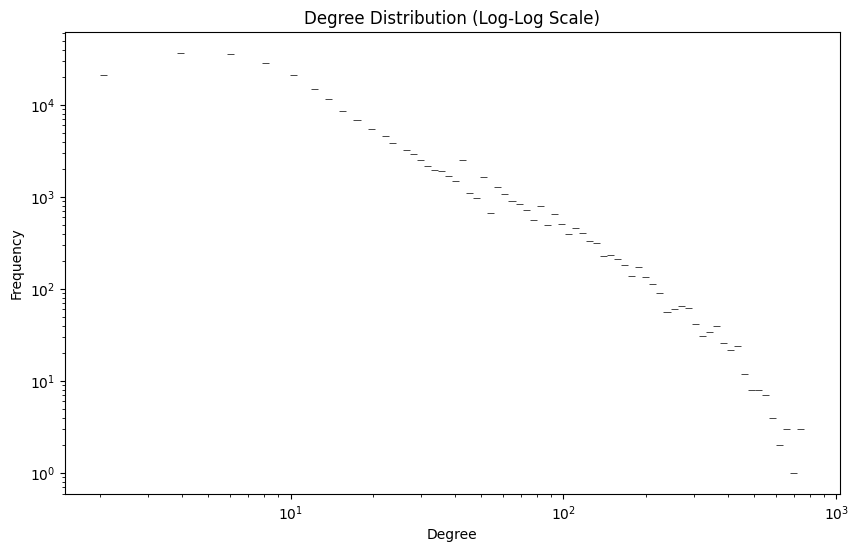

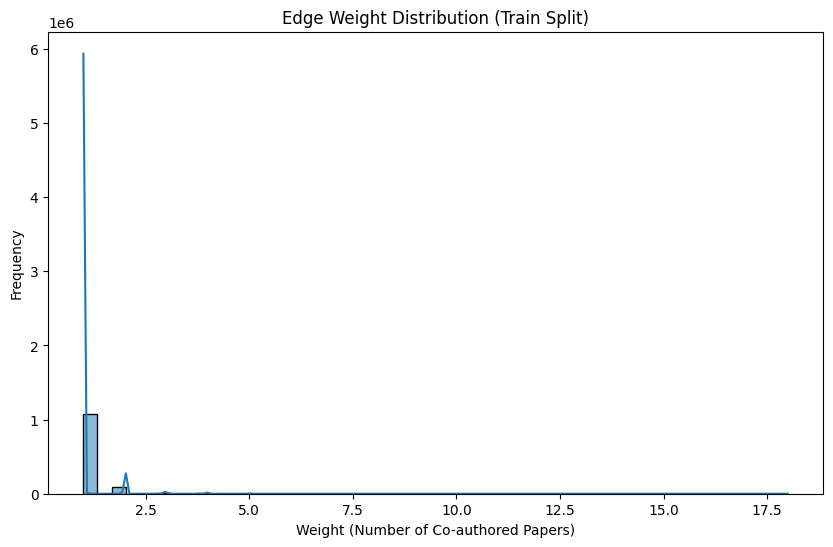

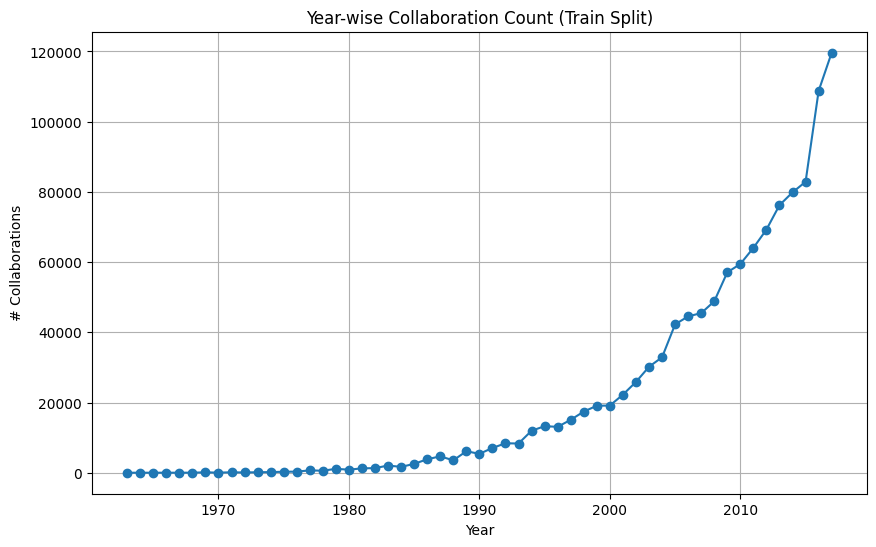

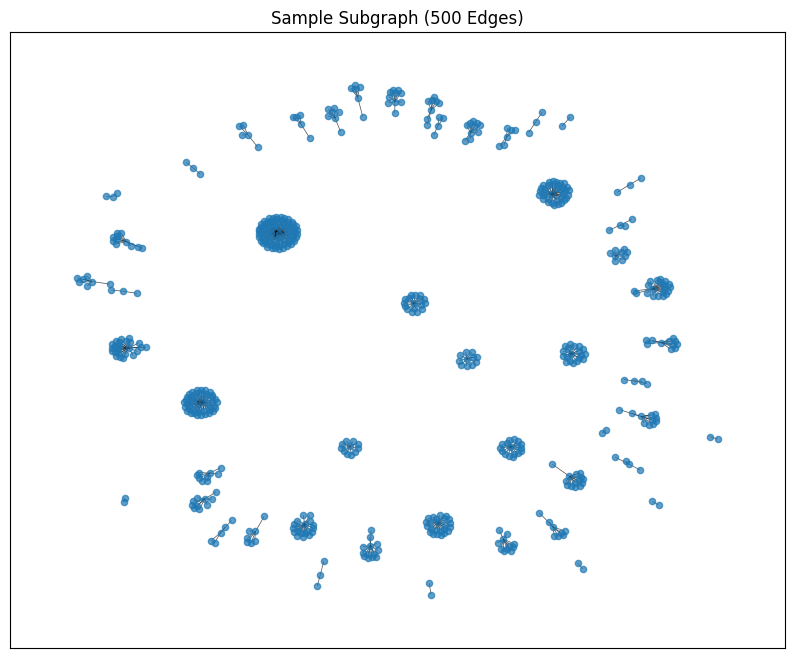

In [ ]:
edges = data.edge_index.numpy().T

# 1. Degree Distribution
degrees = torch.bincount(data.edge_index.flatten()).numpy()
plt.figure(figsize=(10, 6))
sns.histplot(degrees, bins=100, log_scale=(True, True))
plt.title("Degree Distribution (Log-Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

# 2. Edge Weight Distribution
weights = split_edge['train'].get('weight', None)
if weights is not None:
    plt.figure(figsize=(10, 6))
    sns.histplot(weights.numpy(), bins=50, kde=True)
    plt.title("Edge Weight Distribution (Train Split)")
    plt.xlabel("Weight (Number of Co-authored Papers)")
    plt.ylabel("Frequency")
    plt.show()

# 3. Year-wise collaboration dynamics
edge_years = split_edge['train']['year']
year_counts = pd.Series(edge_years.numpy()).value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.xlabel("Year")
plt.ylabel("# Collaborations")
plt.title("Year-wise Collaboration Count (Train Split)")
plt.grid(True)
plt.show()


# 4. Subgraph Visualization
plt.figure(figsize=(10, 8))
# Sample a small number of edges for a readable plot
sample_edges = edges[:500]
G = nx.Graph()
G.add_edges_from(sample_edges)
nx.draw_networkx(G, node_size=20, with_labels=False, width=0.5, alpha=0.7)
plt.title("Sample Subgraph (500 Edges)")
plt.show()

### 3. Model Architecture

Define a two-layer GraphSAGE model to generate node embeddings, and a simple `LinkPredictor` to score potential edges.

In [ ]:
class GraphSAGE(nn.Module):
    """
    A two-layer GraphSAGE model for generating node embeddings.
    """
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class LinkPredictor(nn.Module):
    """
    A simple MLP to predict the existence of a link based on node embeddings.
    """
    def __init__(self, in_channels):
        super().__init__()
        self.fc1 = nn.Linear(in_channels * 2, in_channels)
        self.fc2 = nn.Linear(in_channels, 1)

    def forward(self, x_i, x_j):
        x = torch.cat([x_i, x_j], dim=-1)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        return self.fc2(x).squeeze(-1)

### 4. Training and Evaluation Setup

Defining the core logic for training and evaluation.

- **`train()`**: The main training function. It computes node embeddings, predicts link scores, calculates loss, and updates model weights.
- **`test()`**: The evaluation function, which computes Hits@50 on the validation and test sets using the OGB `Evaluator`.

In [ ]:
def train(model, predictor, data, split_edge, optimizer, batch_size, device):
    model.train()
    predictor.train()

    pos_train_edge = split_edge['train']['edge'].to(device)

    total_loss = 0
    for perm in DataLoader(range(pos_train_edge.size(0)), batch_size, shuffle=True):
        optimizer.zero_grad()
         # Compute node embeddings once per epoch
        z = model(data.x.to(device), data.edge_index.to(device))
        # Positive edges
        pos_edge = pos_train_edge[perm]
        pos_out = predictor(z[pos_edge[:, 0]], z[pos_edge[:, 1]])

        # Negative edges (just-in-time sampling)
        neg_edge = torch.randint(0, data.num_nodes, pos_edge.size(), dtype=torch.long, device=device)
        neg_out = predictor(z[neg_edge[:, 0]], z[neg_edge[:, 1]])

        # Compute loss
        pos_loss = F.binary_cross_entropy_with_logits(pos_out, torch.ones_like(pos_out))
        neg_loss = F.binary_cross_entropy_with_logits(neg_out, torch.zeros_like(neg_out))
        loss = pos_loss + neg_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(predictor.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / (pos_train_edge.size(0) / batch_size)

@torch.no_grad()
def test(model, predictor, data, split_edge, evaluator, batch_size, device):
    model.eval()
    predictor.eval()

    z = model(data.x.to(device), data.edge_index.to(device))

    # --- Validation Set ---
    pos_valid_edge = split_edge['valid']['edge'].to(device)
    neg_valid_edge = split_edge['valid']['edge_neg'].to(device)

    pos_valid_preds = []
    for perm in DataLoader(range(pos_valid_edge.size(0)), batch_size):
        edge = pos_valid_edge[perm]
        pos_valid_preds += [predictor(z[edge[:, 0]], z[edge[:, 1]]).cpu()]
    pos_valid_pred = torch.cat(pos_valid_preds, dim=0)

    neg_valid_preds = []
    for perm in DataLoader(range(neg_valid_edge.size(0)), batch_size):
        edge = neg_valid_edge[perm]
        neg_valid_preds += [predictor(z[edge[:, 0]], z[edge[:, 1]]).cpu()]
    neg_valid_pred = torch.cat(neg_valid_preds, dim=0)

    valid_hits = evaluator.eval({
        'y_pred_pos': pos_valid_pred,
        'y_pred_neg': neg_valid_pred,
    })['hits@50']

    # --- Test Set ---
    pos_test_edge = split_edge['test']['edge'].to(device)
    neg_test_edge = split_edge['test']['edge_neg'].to(device)

    pos_test_preds = []
    for perm in DataLoader(range(pos_test_edge.size(0)), batch_size):
        edge = pos_test_edge[perm]
        pos_test_preds += [predictor(z[edge[:, 0]], z[edge[:, 1]]).cpu()]
    pos_test_pred = torch.cat(pos_test_preds, dim=0)

    neg_test_preds = []
    for perm in DataLoader(range(neg_test_edge.size(0)), batch_size):
        edge = neg_test_edge[perm]
        neg_test_preds += [predictor(z[edge[:, 0]], z[edge[:, 1]]).cpu()]
    neg_test_pred = torch.cat(neg_test_preds, dim=0)

    test_hits = evaluator.eval({
        'y_pred_pos': pos_test_pred,
        'y_pred_neg': neg_test_pred,
    })['hits@50']

    return valid_hits, test_hits

### 5. Model Training

Now we set up the training environment and run the main loop.

- **Device**: Use CUDA if available, otherwise CPU.
- **Hyperparameters**: We define learning rate, hidden dimensions, epochs, etc.
- **Optimizer**: Adam is used for both the GNN and the predictor.
- **Early Stopping**: We monitor the validation `Hits@50` and stop if it doesn't improve for a set number of epochs (`patience`).

In [ ]:
# --- Hyperparameters ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
HIDDEN_CHANNELS = 256
OUT_CHANNELS = 256
LEARNING_RATE = 0.001
BATCH_SIZE = 64 * 1024  # 65536
EPOCHS = 20
PATIENCE = 5

print(f"Using device: {DEVICE}")

# --- Model Initialization ---
model = GraphSAGE(data.x.size(-1), HIDDEN_CHANNELS, OUT_CHANNELS).to(DEVICE)
predictor = LinkPredictor(OUT_CHANNELS).to(DEVICE)
evaluator = Evaluator(name='ogbl-collab')
optimizer = torch.optim.Adam(
    list(model.parameters()) + list(predictor.parameters()),
    lr=LEARNING_RATE
)

# --- Training Loop ---
best_valid_hits = 0
wait = 0
history = {'loss': [], 'valid_hits': [], 'test_hits': []}

for epoch in range(1, EPOCHS + 1):
    loss = train(model, predictor, data, split_edge, optimizer, BATCH_SIZE, DEVICE)
    valid_hits, test_hits = test(model, predictor, data, split_edge, evaluator, BATCH_SIZE, DEVICE)

    history['loss'].append(loss)
    history['valid_hits'].append(valid_hits)
    history['test_hits'].append(test_hits)

    print(f"Epoch {epoch:02d}:")
    print(f"  Loss: {loss:.4f}")
    print(f"  Validation Hits@50: {valid_hits:.4f}")
    print(f"  Test Hits@50: {test_hits:.4f}")

    if valid_hits > best_valid_hits:
        best_valid_hits = valid_hits
        # Save the best model state
        torch.save(model.state_dict(), 'best_model.pt')
        torch.save(predictor.state_dict(), 'best_predictor.pt')
        wait = 0
    else:
        wait += 1

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. No improvement for {PATIENCE} epochs.")
        break

    gc.collect()

print(f"Training finished. Best Validation Hits@50: {best_valid_hits:.4f}")

Using device: cpu
Epoch 01:
  Loss: 1.3150
  Validation Hits@50: 0.0195
  Test Hits@50: 0.0269
Epoch 02:
  Loss: 0.8604
  Validation Hits@50: 0.0107
  Test Hits@50: 0.0188
Epoch 03:
  Loss: 0.5286
  Validation Hits@50: 0.0519
  Test Hits@50: 0.0358
Epoch 04:
  Loss: 0.4162
  Validation Hits@50: 0.0655
  Test Hits@50: 0.0472
Epoch 05:
  Loss: 0.3633
  Validation Hits@50: 0.0829
  Test Hits@50: 0.0653
Epoch 06:
  Loss: 0.3345
  Validation Hits@50: 0.1158
  Test Hits@50: 0.0949
Epoch 07:
  Loss: 0.3175
  Validation Hits@50: 0.1119
  Test Hits@50: 0.0943
Epoch 08:
  Loss: 0.3036
  Validation Hits@50: 0.1273
  Test Hits@50: 0.1066
Epoch 09:
  Loss: 0.2921
  Validation Hits@50: 0.1367
  Test Hits@50: 0.1118
Epoch 10:
  Loss: 0.2829
  Validation Hits@50: 0.1413
  Test Hits@50: 0.1160
Epoch 11:
  Loss: 0.2752
  Validation Hits@50: 0.1452
  Test Hits@50: 0.1198
Epoch 12:
  Loss: 0.2707
  Validation Hits@50: 0.1492
  Test Hits@50: 0.1211
Epoch 13:
  Loss: 0.2658
  Validation Hits@50: 0.1462
  Te

### 6. Results and Analysis

After training, we analyze the model's performance.

- **Training Curves**: We plot the loss and Hits@50 over epochs to see the learning progression.
- **Node Embeddings**: We use t-SNE to visualize the learned author embeddings in 2D space. This can reveal clusters of authors with similar collaboration patterns.

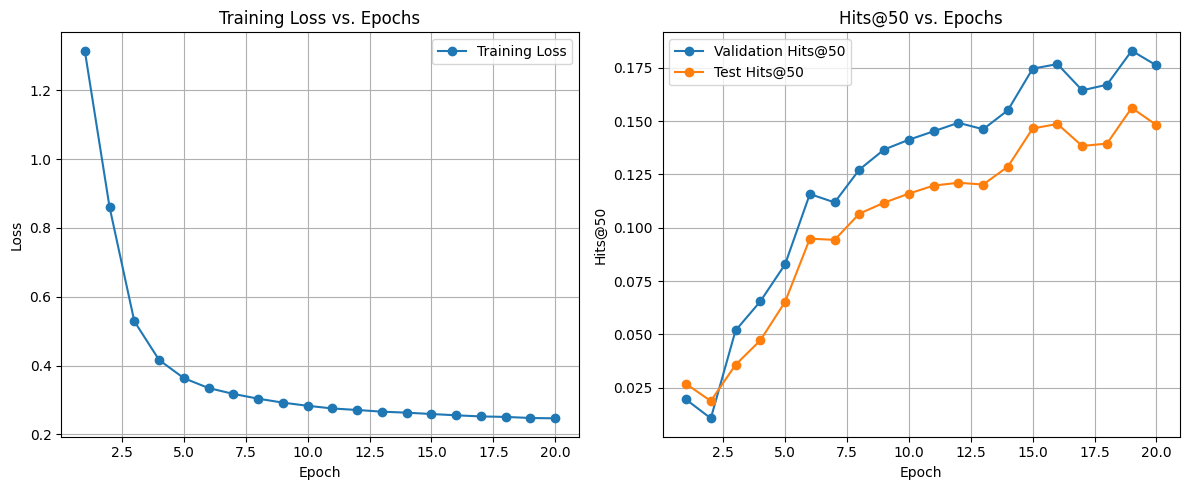

In [ ]:
# Plotting training curves
epochs_ran = range(1, len(history['loss']) + 1)

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, history['loss'], label='Training Loss', marker='o')
plt.title('Training Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Hits@50 Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_ran, history['valid_hits'], label='Validation Hits@50', marker='o')
plt.plot(epochs_ran, history['test_hits'], label='Test Hits@50', marker='o')
plt.title('Hits@50 vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Hits@50')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Generating t-SNE plot... (this may take a moment)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.002s...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 5000 samples in 0.232s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.467296
[t-SNE] KL divergence after 250 iterations with early exaggeration: 70.661140
[t-SNE] KL divergence after 300 iterations: 2.036739


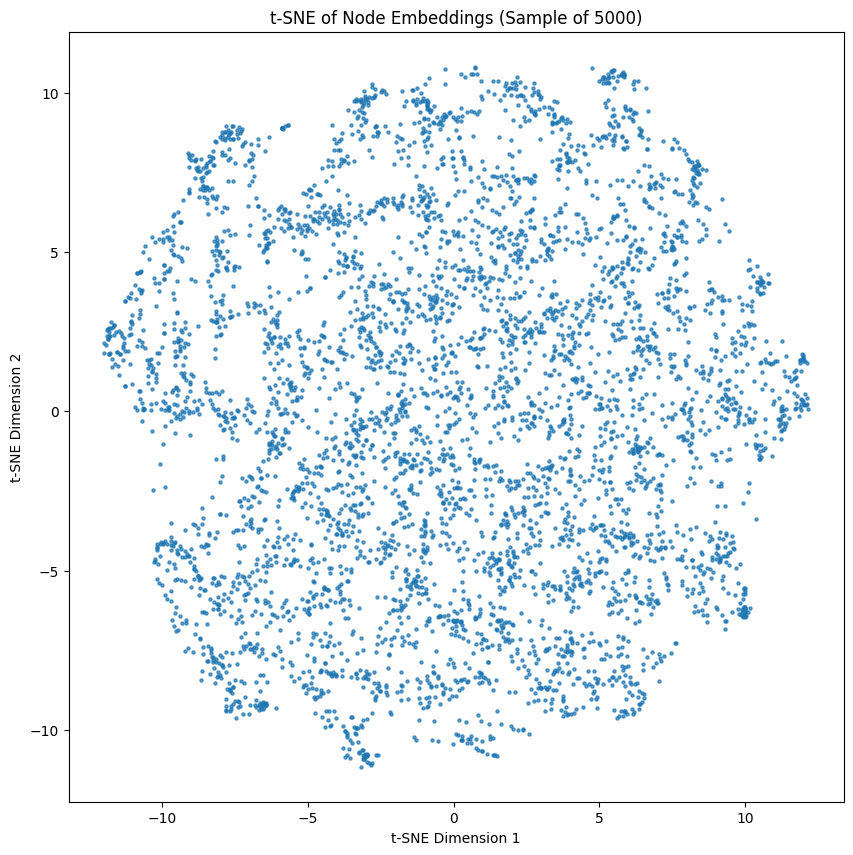

In [ ]:
# Visualize embeddings with t-SNE
from sklearn.manifold import TSNE

# Load the best model for generating final embeddings
try:
    model.load_state_dict(torch.load('best_model.pt'))
    model.eval()

    with torch.no_grad():
        z = model(data.x.to(DEVICE), data.edge_index.to(DEVICE)).cpu().numpy()

    print("Generating t-SNE plot... (this may take a moment)")
    tsne = TSNE(n_components=2, random_state=42, n_iter=300, verbose=1)

    # Sample a subset of nodes for faster t-SNE
    sample_size = 5000
    indices = np.random.choice(z.shape[0], sample_size, replace=False)
    z_sample = z[indices]

    z_tsne = tsne.fit_transform(z_sample)

    plt.figure(figsize=(10, 10))
    plt.scatter(z_tsne[:, 0], z_tsne[:, 1], s=5, alpha=0.7)
    plt.title(f't-SNE of Node Embeddings (Sample of {sample_size})')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.show()
except FileNotFoundError:
    print("Could not load 'best_model.pt'. Run the training loop first.")
except Exception as e:
    print(f"An error occurred during t-SNE plotting: {e}")